# 

# Calculate titers of H5 HA pseudotyped lentiviruses

In [1]:
import os
import warnings

import math
import numpy as np 

from IPython.display import display, HTML
import matplotlib.pyplot as plt

from neutcurve.colorschemes import CBMARKERS, CBPALETTE
from mizani.formatters import scientific_format

import pandas as pd
from pandas.api.types import CategoricalDtype

from plotnine import *
import altair as alt
from pandas.api.types import CategoricalDtype



In [2]:
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
warnings.simplefilter('ignore')

Read config


In [4]:
titers = pd.read_csv('data/virus_titer_RLU.csv')

titers = (titers
          .assign(RLUperuL=lambda x: x['RLU_per_well'] / x['uL_virus']
                 )
         )

display(HTML(titers.head().to_html(index=False)))

replicate,virus,dilution,uL_virus,RLU_per_well,cells,oseltamivir,media,RLUperuL
rep1,1918_NYC,0.250000,25.0000,39170.0,293-SA23,no,IGM,1566.80
rep1,1918_NYC,0.125000,12.5000,25920.0,293-SA23,no,IGM,2073.60
rep1,1918_NYC,0.062500,6.2500,14570.0,293-SA23,no,IGM,2331.20
rep1,1918_NYC,0.031250,3.1250,6590.0,293-SA23,no,IGM,2108.80
rep1,1918_NYC,0.015625,1.5625,494.5,293-SA23,no,IGM,316.48


In [5]:
ncol=min(8, titers['virus'].nunique())
nrow=math.ceil(titers['virus'].nunique() / ncol)

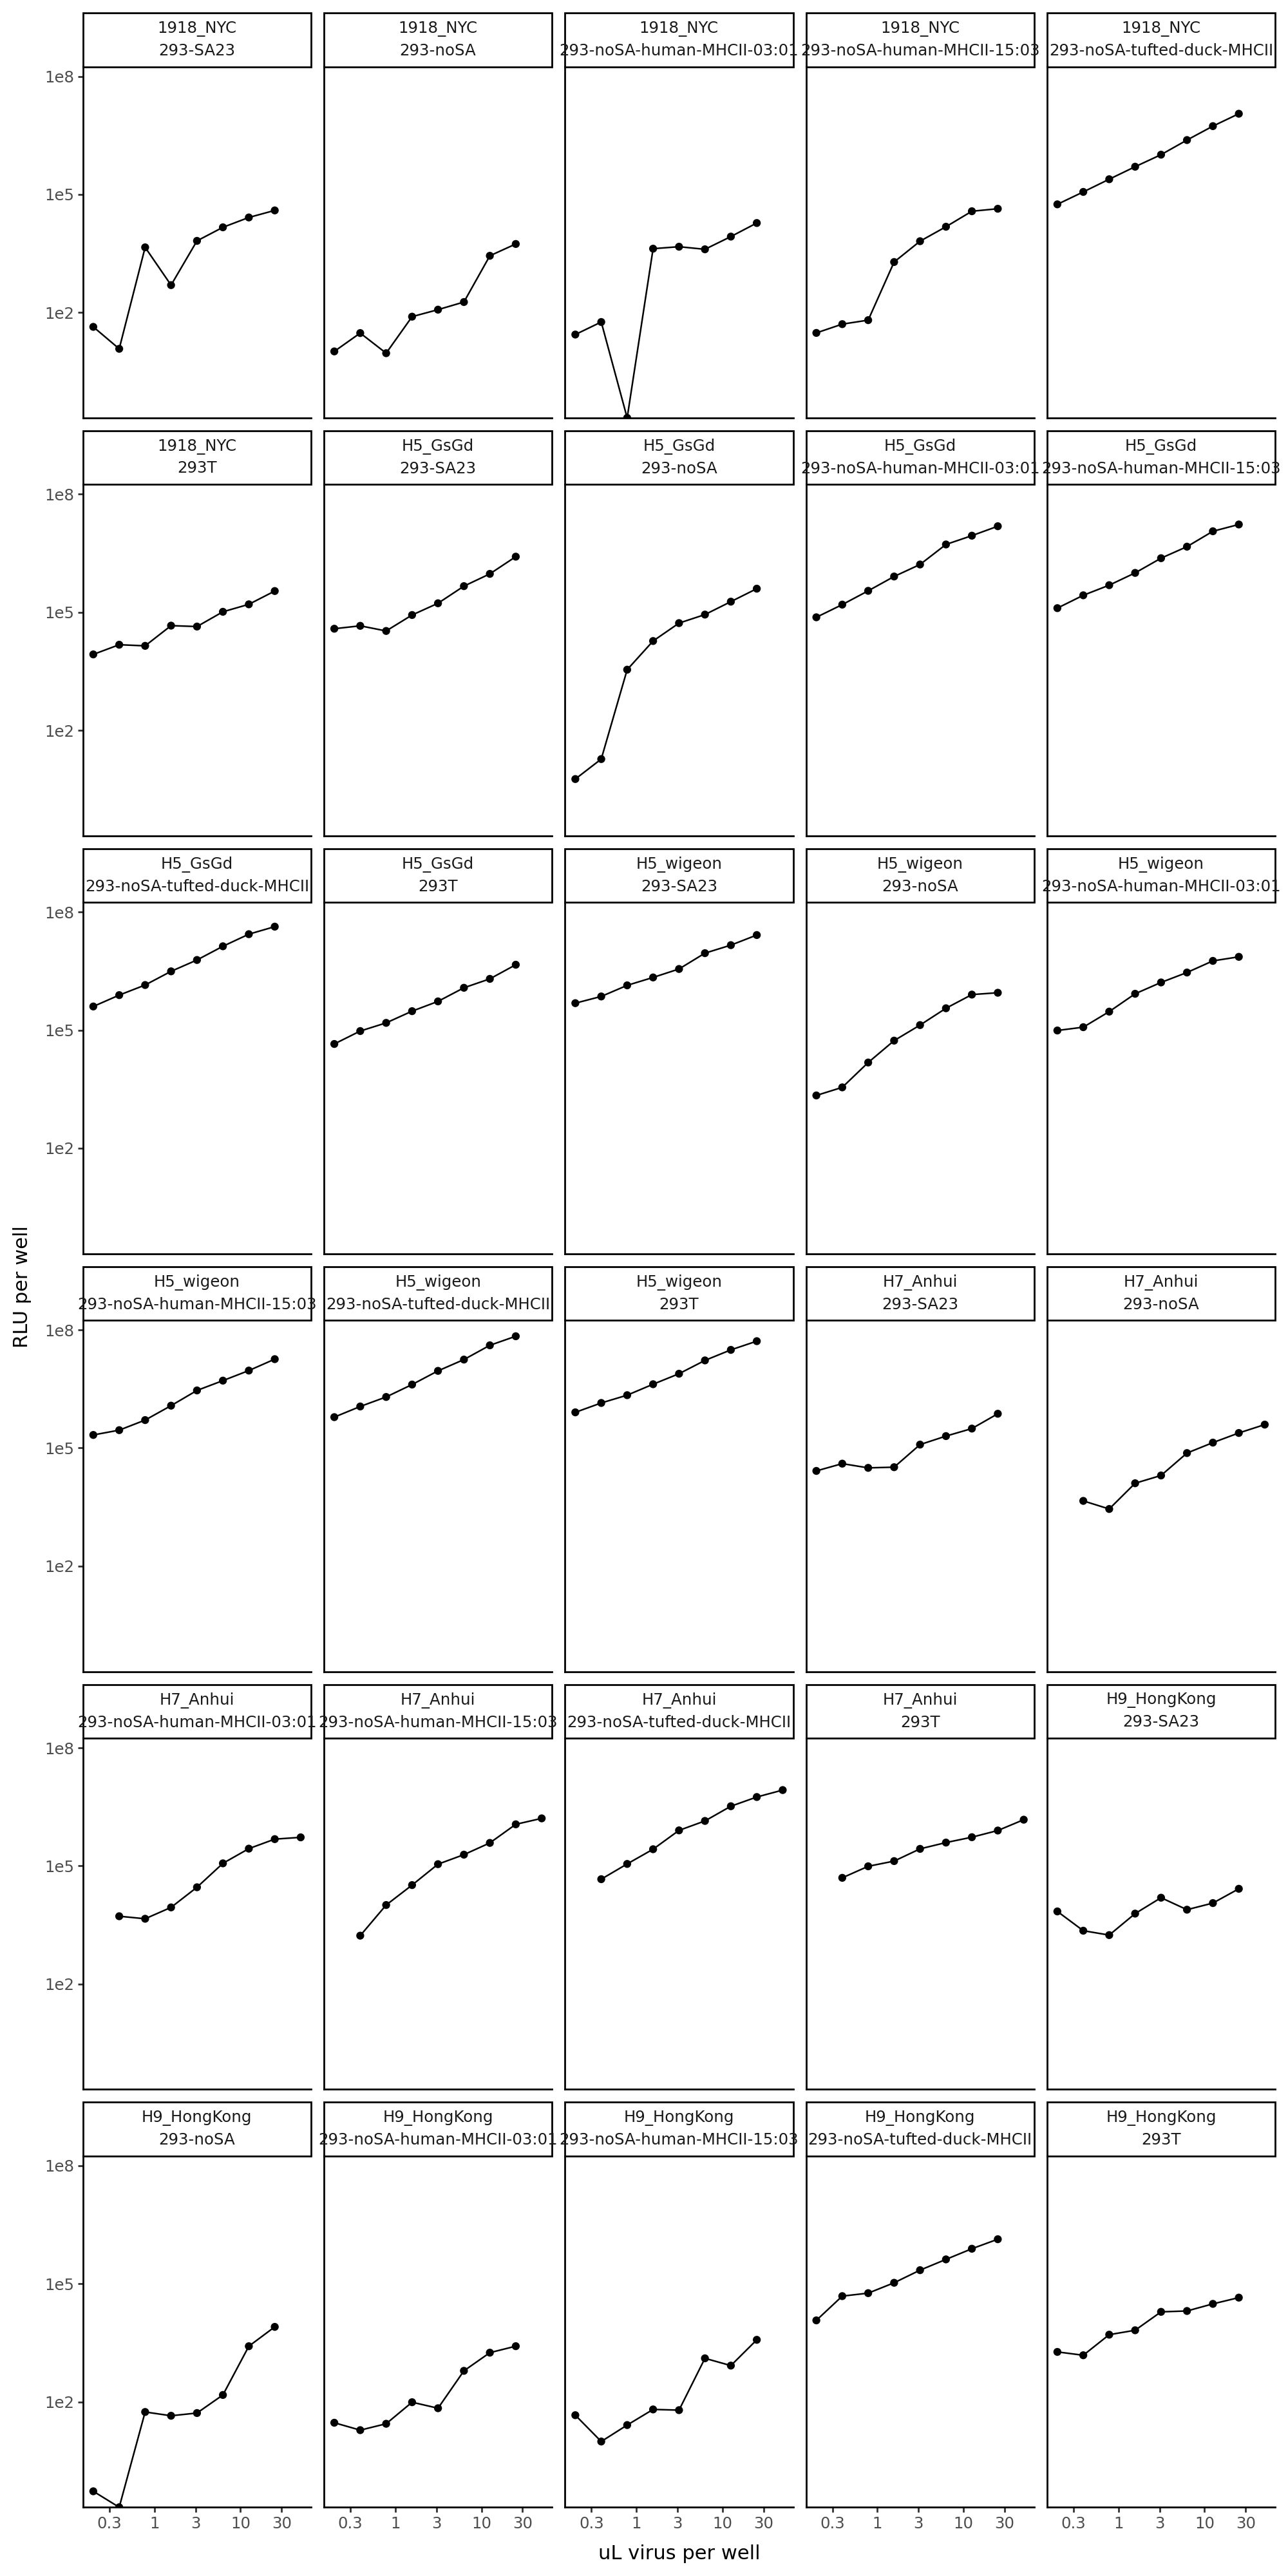

In [6]:
p = (ggplot(titers.dropna()
            ) +
     aes('uL_virus', 'RLU_per_well') +
     geom_point(size=1.5) +
     geom_line() +
     facet_wrap('~virus+cells', ncol=5) +
     scale_y_log10(name='RLU per well') +
     scale_x_log10(name='uL virus per well') +
     theme_classic() +
     theme(axis_text_x=element_text(),
           figure_size=(10,20),
           )
     )

p

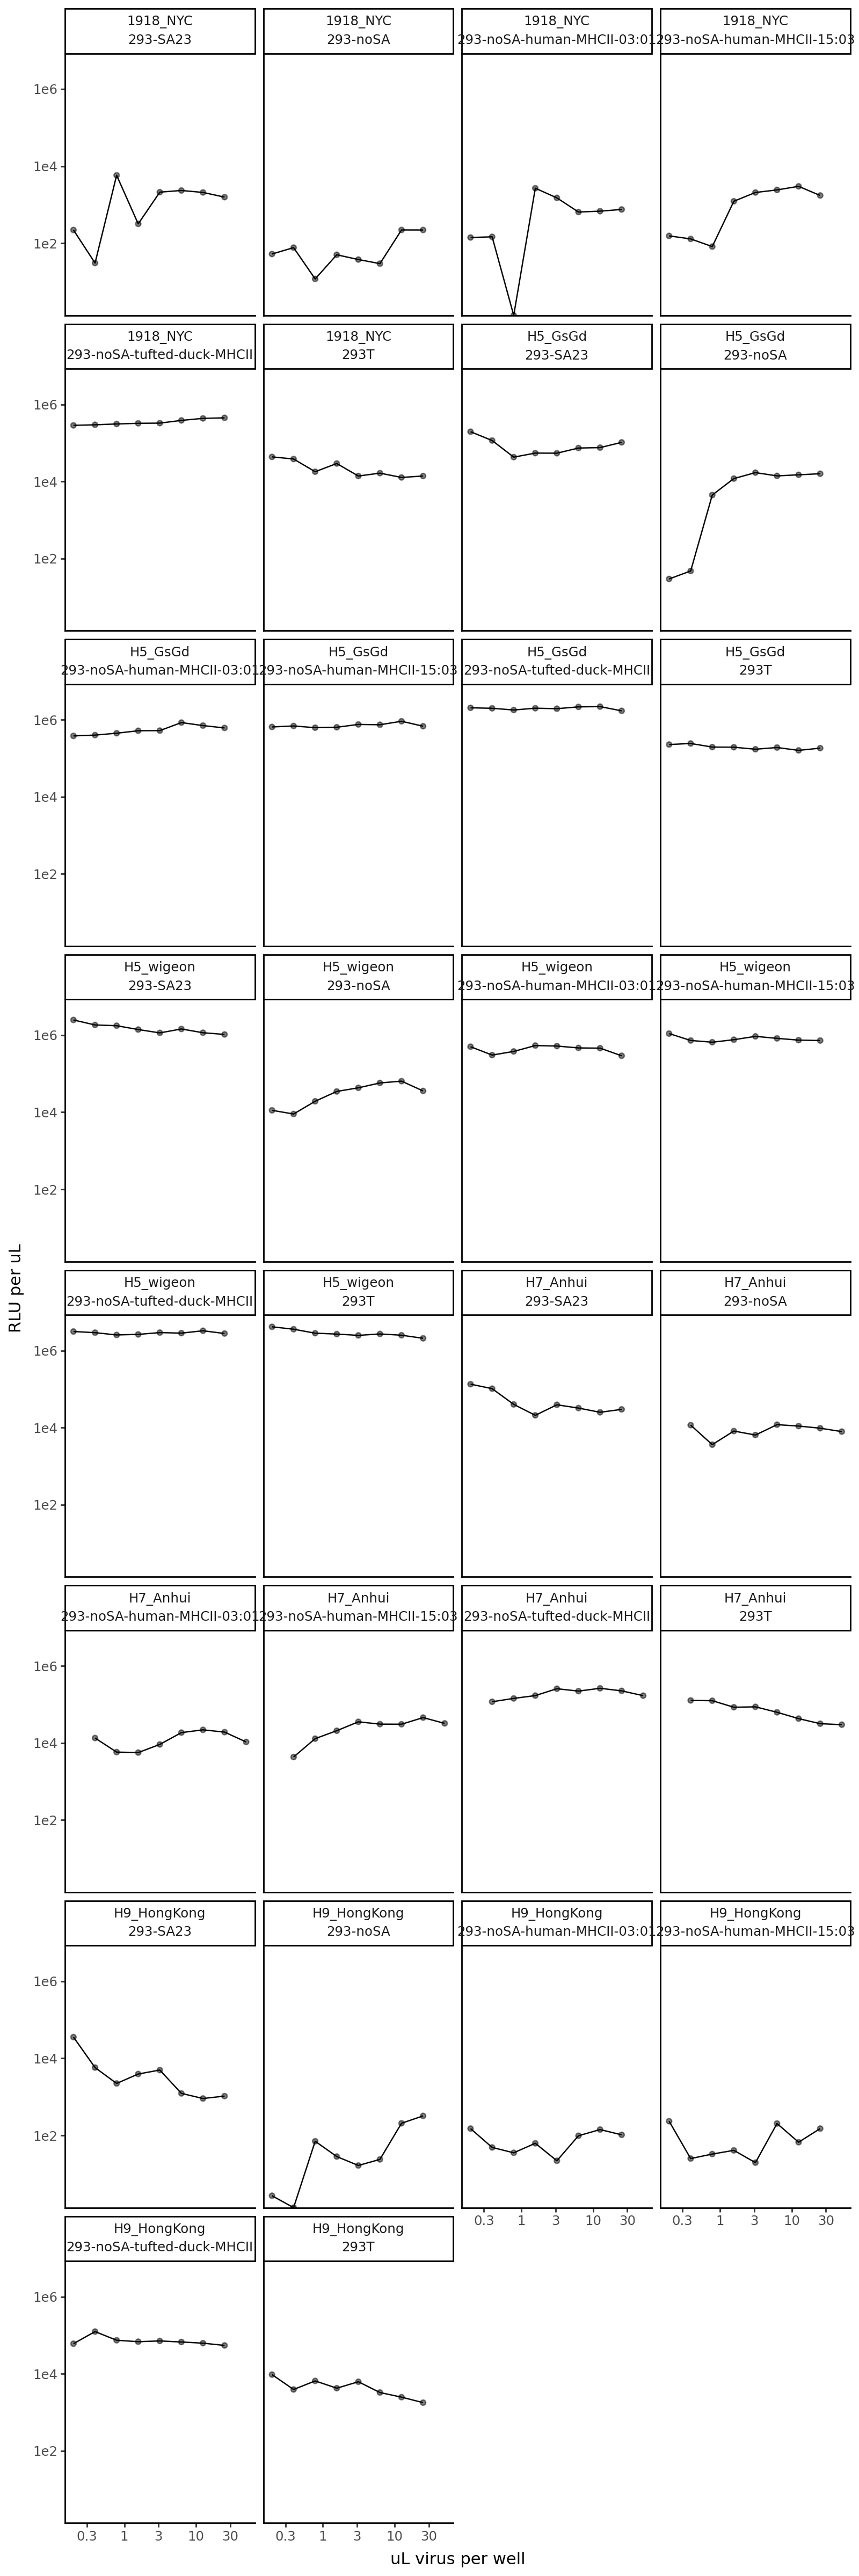

In [7]:
p = (ggplot(titers.dropna()
            ) +
     aes('uL_virus', 'RLUperuL', group='replicate') +
     geom_point(size=1.5, alpha=0.5) +
     geom_line() +
     facet_wrap('~virus+cells', ncol=4) +
     scale_y_log10(name='RLU per uL') +
     scale_x_log10(name='uL virus per well') +
     theme_classic() +
     theme(axis_text_x=element_text(),
           figure_size=(8,24),
           ) 
     )

p

Check that above plots are approximately linear 

In [8]:
average_titers = (titers
                  .dropna() # missing values for some replicates
                  .query('uL_virus > 1') # dropping 3 lowest volumes as they seem to have low nonlinear signal
                  .groupby(['virus', "cells", 'oseltamivir', 'media'])
                  .agg(mean_RLUperuL=pd.NamedAgg(column='RLUperuL', aggfunc=np.mean))
                  .reset_index()
                 )
average_titers.to_csv('virus_titers.csv', index=False)

display(HTML(average_titers.head().to_html(index=False)))

virus,cells,oseltamivir,media,mean_RLUperuL
1918_NYC,293-SA23,no,IGM,1679.37600
1918_NYC,293-noSA,no,IGM,111.39616
1918_NYC,293-noSA-human-MHCII-03:01,no,IGM,1247.42400
1918_NYC,293-noSA-human-MHCII-15:03,no,IGM,2082.36800
1918_NYC,293-noSA-tufted-duck-MHCII,no,IGM,383657.60000


In [9]:

virus_order = [
    'H5_wigeon', 'H5_GsGd', '1918_NYC', 'H9_HongKong', 'H7_Anhui'
]

cells_order = [
    '293-SA23', "293T", '293-noSA', '293-noSA-tufted-duck-MHCII',
    '293-noSA-human-MHCII-15:03','293-noSA-human-MHCII-03:01',
]

In [10]:
CBPALETTE = ('#E69F00','#56B4E9','#999999','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7')

average_titers = average_titers.copy()

average_titers["virus"] = average_titers["virus"].astype(
    CategoricalDtype(categories=virus_order, ordered=True)
)

average_titers["cells"] = average_titers["cells"].astype(
    CategoricalDtype(categories=cells_order, ordered=True)
)

base = alt.Chart(average_titers).encode(
    x=alt.X(
        "cells:N",
        sort=cells_order,
        title=None,
        axis=alt.Axis(
            labelAngle=90,
            labelFontSize=14,
            labelLimit=0
        ),
    ),
    y=alt.Y(
        "mean_RLUperuL:Q",
        scale=alt.Scale(type="log", domain=[10, 1e8]),
        title="RLU per µL",
        axis=alt.Axis(
            titleFontSize=14,
            labelFontSize=12,
            format=".0e"
        ),
    ),
    color=alt.Color(
        "virus:N",
        scale=alt.Scale(range=CBPALETTE),
        legend=alt.Legend(
            title="virus",
            orient="bottom",
            titleFontSize=13,
            labelFontSize=12,
            labelLimit=0
        ),
    ),
    tooltip=[
        "virus:N",
        "cells:N",
        alt.Tooltip("mean_RLUperuL:Q", format=".2e"),
    ],
)

points = base.mark_point(
    size=300,
    filled=True,
    opacity=0.9,
    stroke="black",
    strokeWidth=1,
)


chart = (
    alt.layer(points)
    .properties(
        width=180,
        height=180
    )
    .facet(
        column=alt.Column(
            "virus:N",
            sort=virus_order,
            header=alt.Header(
                title=None,
                labelFontSize=18,
                labelOrient="top",
            ),
        ),
        columns=4,
    )
    .properties(
        title="variant titers on different cell lines"
    )
    .resolve_scale(
        y="shared"
    )
    .configure_axis(
        grid=False
    )
    .configure_view(
        stroke=None
    )
    .configure_title(
        fontSize=16
    )
    .configure_facet(
        spacing=20
    )
)

chart

alt.FacetChart(...)

In [11]:
# ── Save chart as html ─────────────────────────────────────────────────────────
OUTPUT_html= './virus_titers_by_strain.html'
# save as HTML
chart.save(OUTPUT_html)
print(f"✓ Chart saved as HTML: {OUTPUT_html}")

✓ Chart saved as HTML: ./virus_titers_by_strain.html


In [12]:
CBPALETTE = ('#999999','#56B4E9','#E69F00','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7')

df = average_titers.copy()

# get baseline mean_RLUperuL for each virus in 293-noSA cells
baseline = (
    df.loc[df["cells"] == "293-noSA", ["virus", "mean_RLUperuL"]]
    .rename(columns={"mean_RLUperuL": "mean_RLUperuL_293_noSA"})
)

# join baseline back onto all rows by virus
df = df.merge(baseline, on="virus", how="left")

# keep only the cell lines you want to compare against 293-noSA
df = df[df["cells"].isin(cells_order)].copy()

# calculate fold-change over 293-noSA
df["RLU_over_293_noSA"] = df["mean_RLUperuL"] / df["mean_RLUperuL_293_noSA"]

# set ordering
df["virus"] = df["virus"].astype(
    CategoricalDtype(categories=virus_order, ordered=True)
)

df["cells"] = df["cells"].astype(
    CategoricalDtype(categories=cells_order, ordered=True)
)

df["virus"] = df["virus"].astype(
    CategoricalDtype(categories=virus_order, ordered=True)
)

df["cells"] = df["cells"].astype(
    CategoricalDtype(categories=cells_order, ordered=True)
)

base = alt.Chart(df).encode(
    x=alt.X(
        "cells:N",
        sort=cells_order,
        title=None,
        axis=alt.Axis(
            labelAngle=90,
            labelFontSize=14,
            labelLimit=0
        ),
    ),
    y=alt.Y(
        "RLU_over_293_noSA:Q",
        scale=alt.Scale(type="log", domain=[1, 10000]),
        title="mean_RLUperuL / mean_RLUperuL in 293-noSA",
        axis=alt.Axis(
            titleFontSize=14,
            labelFontSize=12
        ),
    ),
    color=alt.Color(
        "virus:N",
        sort=virus_order,
        scale=alt.Scale(range=CBPALETTE),
        legend=alt.Legend(
            title="virus",
            orient="bottom",
            titleFontSize=13,
            labelFontSize=12,
            labelLimit=0
        ),
    ),
    tooltip=[
        "virus:N",
        "cells:N",
        alt.Tooltip("RLU_over_293_noSA:Q"),
    ],
)

points = base.mark_point(
    size=300,
    filled=True,
    opacity=0.9,
    stroke="black",
    strokeWidth=1,
)

hline = alt.Chart(df).mark_rule(
    strokeDash=[6, 6],
    color="black"
).encode(
    y=alt.datum(1)
)

chart = (
    alt.layer(hline, points)
    .properties(
        width=180,
        height=180
    )
    .facet(
        column=alt.Column(
            "virus:N",
            sort=virus_order,
            header=alt.Header(
                title=None,
                labelFontSize=18,
                labelOrient="top",
            ),
        ),
        columns=4,
    )
    .properties(
        title="change in titers compared to 293-noSA"
    )
    .resolve_scale(
        y="shared"
    )
    .configure_axis(
        grid=False
    )
    .configure_view(
        stroke=None
    )
    .configure_title(
        fontSize=16
    )
    .configure_facet(
        spacing=20
    )
)

chart

alt.FacetChart(...)

In [13]:
# ── Save chart as html ─────────────────────────────────────────────────────────
OUTPUT_html= 'increase_over_noSA_by_strain.html'
# save as HTML
chart.save(OUTPUT_html)
print(f"✓ Chart saved as HTML: {OUTPUT_html}")

✓ Chart saved as HTML: increase_over_noSA_by_strain.html
